# Fraud Detection with Machine Learning

This notebook explores a highly imbalanced financial-transaction dataset and builds a classifier to identify fraudulent transactions.

**Main corrections from the earlier version:**
- uses the complete dataset;
- does **not** convert `step` into fabricated clock hours/dates;
- keeps `category` as a predictive feature;
- learns percentile and merchant-frequency features from the training data only, preventing leakage;
- keeps the test set untouched until the final model evaluation;
- reports Precision, Recall, F1, ROC-AUC, and PR-AUC.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

## 2. Load the dataset

In [2]:
fraud = pd.read_csv('fraud.csv')

print('Dataset shape:', fraud.shape)
display(fraud.head())

Dataset shape: (594643, 10)


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


## 3. Basic data-quality checks

In [3]:
print('Missing values:')
display(fraud.isna().sum().to_frame('missing'))

print('Duplicate rows:', fraud.duplicated().sum())
print('Fraud classes:')
display(fraud['fraud'].value_counts().to_frame('count'))
print(f"Fraud rate: {fraud['fraud'].mean():.2%}")
print('Step range:', fraud['step'].min(), 'to', fraud['step'].max())

Missing values:


,missing
step,0
customer,0
age,0
gender,0
zipcodeOri,0
merchant,0
zipMerchant,0
category,0
amount,0
fraud,0


Duplicate rows: 0
Fraud classes:


,count
fraud,
0,587443
1,7200


Fraud rate: 1.21%
Step range: 0 to 179


### Cleaning categorical text
The dataset stores some categorical values with quote characters (for example, `'F'` or `'es_transportation'`). We remove those quote characters only to make charts and labels easier to read. This does not use the target variable and therefore does not create leakage.

In [4]:
text_cols = ['customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category']

for col in text_cols:
    if col in fraud.columns:
        fraud[col] = fraud[col].astype(str).str.strip("'")

fraud['amount'] = pd.to_numeric(fraud['amount'], errors='coerce')
fraud['fraud'] = fraud['fraud'].astype('int8')

## 4. Exploratory Data Analysis

### 4.1 Target distribution

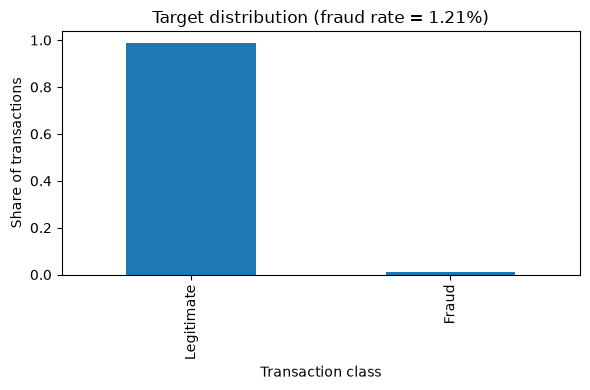

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
(
    fraud['fraud']
    .value_counts(normalize=True)
    .sort_index()
    .rename({0: 'Legitimate', 1: 'Fraud'})
    .plot(kind='bar', ax=ax)
)
ax.set_title(f"Target distribution (fraud rate = {fraud['fraud'].mean():.2%})")
ax.set_xlabel('Transaction class')
ax.set_ylabel('Share of transactions')
plt.tight_layout()
plt.show()

### 4.2 Fraud rate by transaction category

,transactions,fraud_rate
category,,
es_leisure,499,0.949900
es_travel,728,0.793956
es_sportsandtoys,4002,0.495252
es_hotelservices,1744,0.314220
es_otherservices,912,0.250000
es_home,1986,0.152064
es_health,16133,0.105126
es_tech,2370,0.066667
es_wellnessandbeauty,15086,0.047594


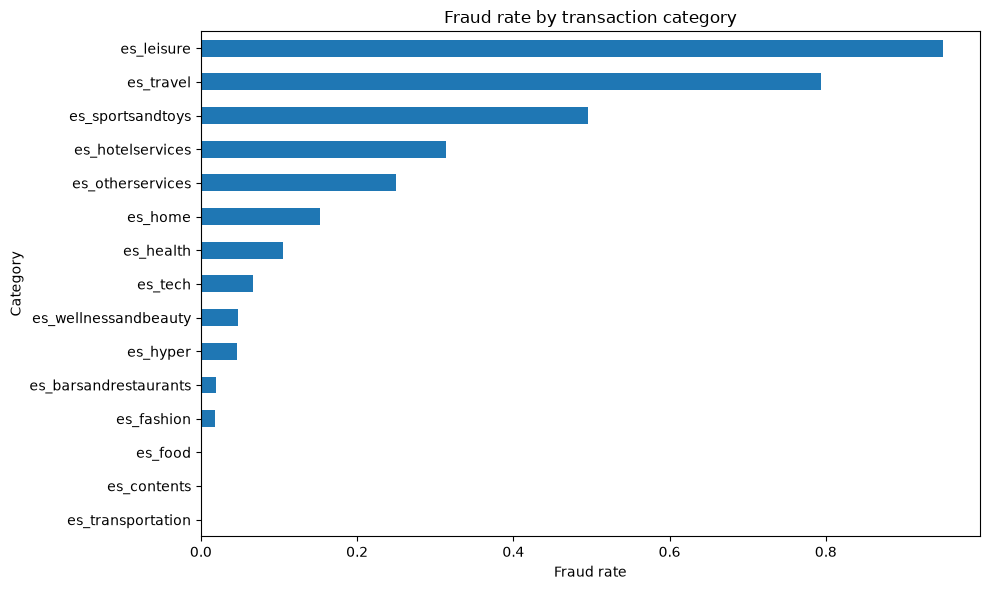

In [6]:
category_summary = (
    fraud.groupby('category', observed=True)
         .agg(transactions=('fraud', 'size'), fraud_rate=('fraud', 'mean'))
         .sort_values('fraud_rate', ascending=False)
)

display(category_summary)

fig, ax = plt.subplots(figsize=(10, 6))
category_summary['fraud_rate'].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Fraud rate by transaction category')
ax.set_xlabel('Fraud rate')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

### 4.3 Transaction amount by class

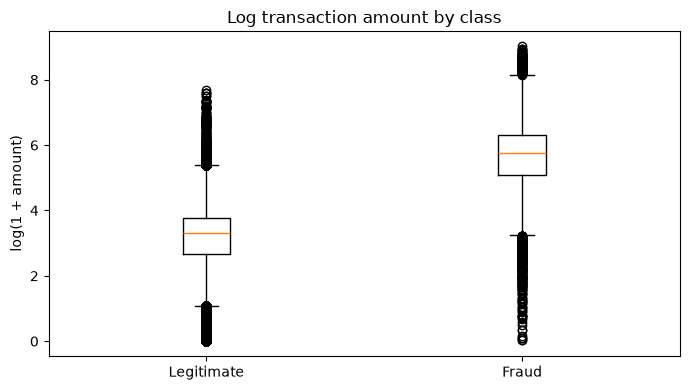

In [7]:
fraud_eda = fraud.copy()
fraud_eda['amount_log'] = np.log1p(fraud_eda['amount'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [
        fraud_eda.loc[fraud_eda['fraud'] == 0, 'amount_log'].dropna(),
        fraud_eda.loc[fraud_eda['fraud'] == 1, 'amount_log'].dropna(),
    ],
    tick_labels=['Legitimate', 'Fraud']
)
ax.set_title('Log transaction amount by class')
ax.set_ylabel('log(1 + amount)')
plt.tight_layout()
plt.show()

### 4.4 Fraud rate across simulation steps

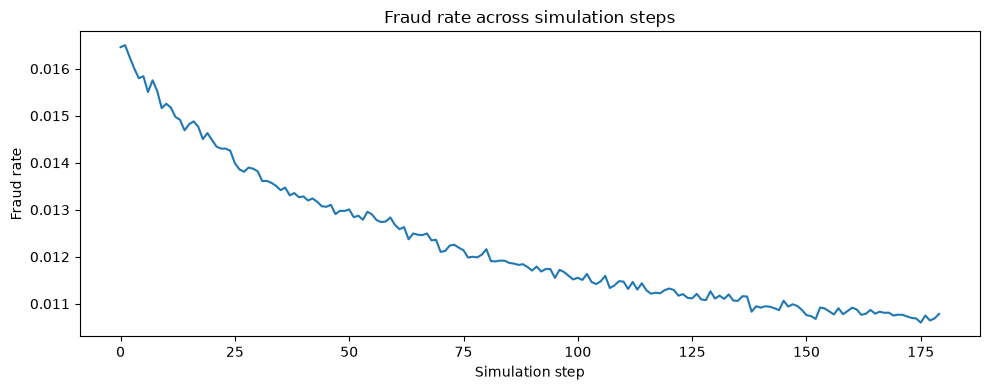

In [8]:
step_summary = fraud.groupby('step', observed=True)['fraud'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
step_summary.plot(ax=ax)
ax.set_title('Fraud rate across simulation steps')
ax.set_xlabel('Simulation step')
ax.set_ylabel('Fraud rate')
plt.tight_layout()
plt.show()

### 4.5 Fraud rate by amount decile

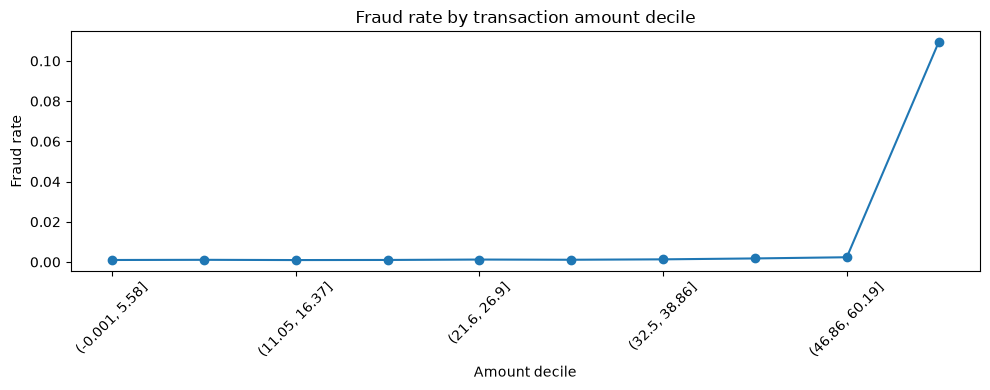

In [9]:
amount_bins = pd.qcut(fraud['amount'], q=10, duplicates='drop')
rate_by_amount = fraud.groupby(amount_bins, observed=True)['fraud'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
rate_by_amount.plot(marker='o', ax=ax)
ax.set_title('Fraud rate by transaction amount decile')
ax.set_xlabel('Amount decile')
ax.set_ylabel('Fraud rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Train / validation / test split

We split the **raw data before learning percentile thresholds or merchant frequencies**. This prevents information from the validation or test sets from influencing training features.

- Training set: 64%
- Validation set: 16%
- Test set: 20%

In [10]:
X_raw = fraud.drop(columns='fraud')
y = fraud['fraud']

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    test_size=0.20,
    stratify=y_trainval,
    random_state=42,
)

print('Training rows:', len(X_train_raw))
print('Validation rows:', len(X_val_raw))
print('Test rows:', len(X_test_raw))
print('Training fraud rate:', round(y_train.mean(), 4))
print('Validation fraud rate:', round(y_val.mean(), 4))
print('Test fraud rate:', round(y_test.mean(), 4))

Training rows: 380571
Validation rows: 95143
Test rows: 118929
Training fraud rate: 0.0121
Validation fraud rate: 0.0121
Test fraud rate: 0.0121


## 6. Leakage-safe feature engineering

The following values are learned **only from the training set**:
- median transaction amount;
- 95th and 99th percentile amount thresholds;
- transaction count for each merchant.

The validation and test sets then receive those same training-derived values.

In [11]:
def fit_feature_params(X):
    amount = pd.to_numeric(X['amount'], errors='coerce')

    return {
        'amount_median': amount.median(),
        'q95': amount.quantile(0.95),
        'q99': amount.quantile(0.99),
        'merchant_counts': X['merchant'].value_counts(),
    }


def make_features(X, params):
    X_new = X.copy()

    amount = pd.to_numeric(X_new['amount'], errors='coerce')
    amount = amount.fillna(params['amount_median'])

    X_new['amount_log'] = np.log1p(amount)
    X_new['amount_ge_95p'] = (amount >= params['q95']).astype('uint8')
    X_new['amount_ge_99p'] = (amount >= params['q99']).astype('uint8')

    X_new['merchant_txn_count'] = (
        X_new['merchant']
        .map(params['merchant_counts'])
        .fillna(0)
        .astype('int32')
    )

    return X_new


feature_params = fit_feature_params(X_train_raw)

X_train = make_features(X_train_raw, feature_params)
X_val = make_features(X_val_raw, feature_params)
X_test = make_features(X_test_raw, feature_params)

## 7. Preprocessing

`age`, `gender`, and **`category`** are encoded inside the pipeline so the transformations are learned from training data. The raw identifiers (`customer`, `merchant`, ZIP-code columns) and raw `amount` are not passed directly to the models.

In [12]:
numeric_cols = ['step', 'amount_log', 'merchant_txn_count']
binary_cols = ['amount_ge_95p', 'amount_ge_99p']
categorical_cols = ['age', 'gender', 'category']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('bin', 'passthrough', binary_cols),
    ('cat', categorical_pipe, categorical_cols),
], remainder='drop')

## 8. Model comparison using the validation set

In [13]:
models = {
    'Logistic Regression': Pipeline([
        ('prep', clone(preprocessor)),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42,
        )),
    ]),

    'Random Forest': Pipeline([
        ('prep', clone(preprocessor)),
        ('clf', RandomForestClassifier(
            n_estimators=250,
            n_jobs=-1,
            random_state=42,
            class_weight='balanced_subsample',
        )),
    ]),

    'Gradient Boosting': Pipeline([
        ('prep', clone(preprocessor)),
        ('clf', GradientBoostingClassifier(random_state=42)),
    ]),
}

threshold_grid = np.arange(0.05, 0.96, 0.05)


def choose_threshold(model, X_validation, y_validation):
    probabilities = model.predict_proba(X_validation)[:, 1]

    rows = []
    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype('int8')
        rows.append({
            'threshold': threshold,
            'precision': precision_score(y_validation, predictions, zero_division=0),
            'recall': recall_score(y_validation, predictions, zero_division=0),
            'f1': f1_score(y_validation, predictions, zero_division=0),
        })

    threshold_table = pd.DataFrame(rows)
    best_row = threshold_table.loc[threshold_table['f1'].idxmax()]
    return float(best_row['threshold']), threshold_table, probabilities


validation_rows = []
trained_models = {}
threshold_tables = {}

for name, model in models.items():
    print('Training:', name)
    model.fit(X_train, y_train)

    best_threshold, threshold_table, p_val = choose_threshold(model, X_val, y_val)
    y_val_pred = (p_val >= best_threshold).astype('int8')

    validation_rows.append({
        'Model': name,
        'Best Threshold': best_threshold,
        'Validation Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Validation Recall': recall_score(y_val, y_val_pred, zero_division=0),
        'Validation F1': f1_score(y_val, y_val_pred, zero_division=0),
        'Validation ROC-AUC': roc_auc_score(y_val, p_val),
        'Validation PR-AUC': average_precision_score(y_val, p_val),
    })

    trained_models[name] = model
    threshold_tables[name] = threshold_table

validation_results = (
    pd.DataFrame(validation_rows)
      .sort_values('Validation F1', ascending=False)
      .reset_index(drop=True)
)

display(validation_results.round(4))

Training: Logistic Regression


Training: Random Forest


Training: Gradient Boosting


,Model,Best Threshold,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Validation PR-AUC
0,Gradient Boosting,0.35,0.8479,0.7891,0.8174,0.9978,0.9001
1,Random Forest,0.55,0.9089,0.7274,0.8081,0.9867,0.8821
2,Logistic Regression,0.95,0.5919,0.7578,0.6646,0.9939,0.7885


## 9. Select the best model and inspect threshold trade-offs

The winning model is selected **using validation F1 only**. The test set has still not been used for model selection.

Selected model: Gradient Boosting
Selected threshold: 0.35


,threshold,precision,recall,f1
0,0.05,0.4912,0.9497,0.6475
1,0.10,0.6353,0.8967,0.7437
2,0.15,0.7337,0.8490,0.7871
3,0.20,0.7693,0.8394,0.8028
4,0.25,0.7925,0.8290,0.8104
5,0.30,0.8220,0.8056,0.8137
6,0.35,0.8479,0.7891,0.8174
7,0.40,0.8692,0.7613,0.8117
8,0.45,0.8825,0.7500,0.8109
9,0.50,0.8898,0.7431,0.8098


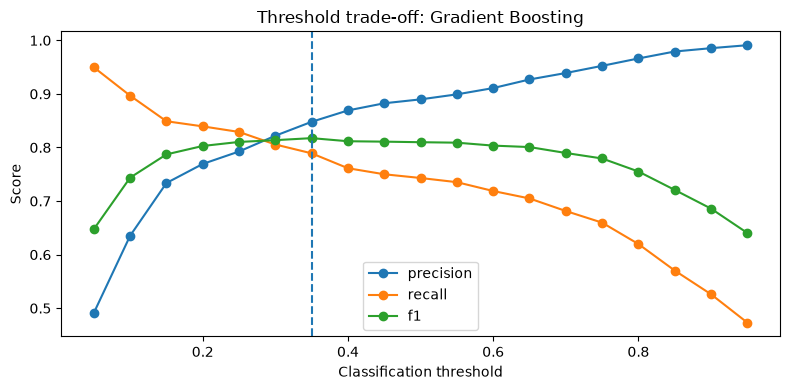

In [14]:
best_name = validation_results.loc[0, 'Model']
best_threshold = float(validation_results.loc[0, 'Best Threshold'])

print('Selected model:', best_name)
print('Selected threshold:', round(best_threshold, 2))

display(threshold_tables[best_name].round(4))

fig, ax = plt.subplots(figsize=(8, 4))
threshold_plot = threshold_tables[best_name].set_index('threshold')
threshold_plot[['precision', 'recall', 'f1']].plot(ax=ax, marker='o')
ax.axvline(best_threshold, linestyle='--')
ax.set_title(f'Threshold trade-off: {best_name}')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

## 10. Final model and untouched test-set evaluation

After model and threshold selection, the training and validation data are combined. Leakage-sensitive feature parameters are learned again from this combined development set. The final model is then evaluated **once** on the untouched test set.

In [15]:
X_final_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_final = pd.concat([y_train, y_val], axis=0)

final_feature_params = fit_feature_params(X_final_raw)
X_final = make_features(X_final_raw, final_feature_params)
X_test_final = make_features(X_test_raw, final_feature_params)

final_model = clone(models[best_name])
final_model.fit(X_final, y_final)

p_test = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (p_test >= best_threshold).astype('int8')

final_metrics = pd.Series({
    'Precision': precision_score(y_test, y_test_pred, zero_division=0),
    'Recall': recall_score(y_test, y_test_pred, zero_division=0),
    'F1': f1_score(y_test, y_test_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, p_test),
    'PR-AUC': average_precision_score(y_test, p_test),
}, name='Test score')

display(final_metrics.to_frame().round(4))
print('\nClassification report:')
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

,Test score
Precision,0.8265
Recall,0.7875
F1,0.8065
ROC-AUC,0.9973
PR-AUC,0.8943



Classification report:
              precision    recall  f1-score   support

           0     0.9974    0.9980    0.9977    117489
           1     0.8265    0.7875    0.8065      1440

    accuracy                         0.9954    118929
   macro avg     0.9120    0.8927    0.9021    118929
weighted avg     0.9953    0.9954    0.9954    118929



### Confusion matrix

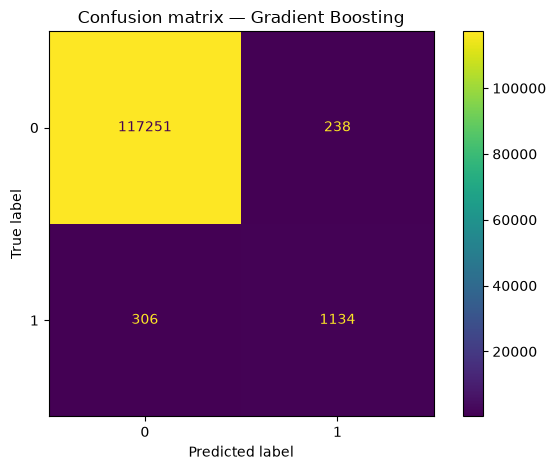

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

### Precision–Recall curve

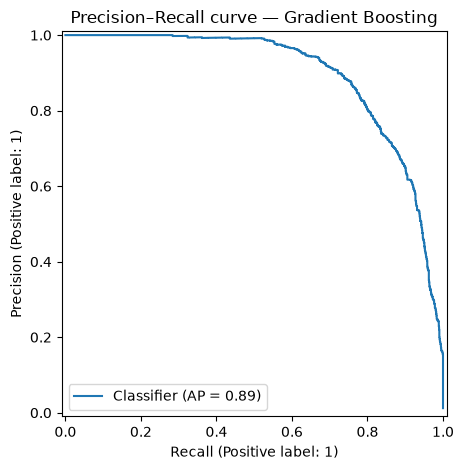

In [17]:
PrecisionRecallDisplay.from_predictions(y_test, p_test)
plt.title(f'Precision–Recall curve — {best_name}')
plt.tight_layout()
plt.show()

### ROC curve

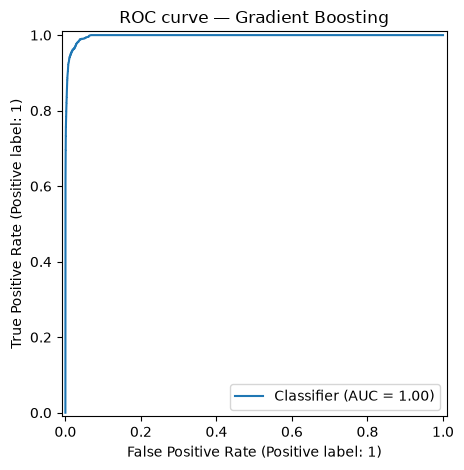

In [18]:
RocCurveDisplay.from_predictions(y_test, p_test)
plt.title(f'ROC curve — {best_name}')
plt.tight_layout()
plt.show()

## 11. Feature importance / model interpretation

,Feature importance
num__amount_log,0.624056
num__merchant_txn_count,0.225002
cat__category_es_sportsandtoys,0.046067
cat__category_es_leisure,0.023477
cat__category_es_health,0.015205
cat__category_es_travel,0.014075
cat__category_es_wellnessandbeauty,0.011301
cat__category_es_hyper,0.008761
num__step,0.007626
cat__category_es_hotelservices,0.005834


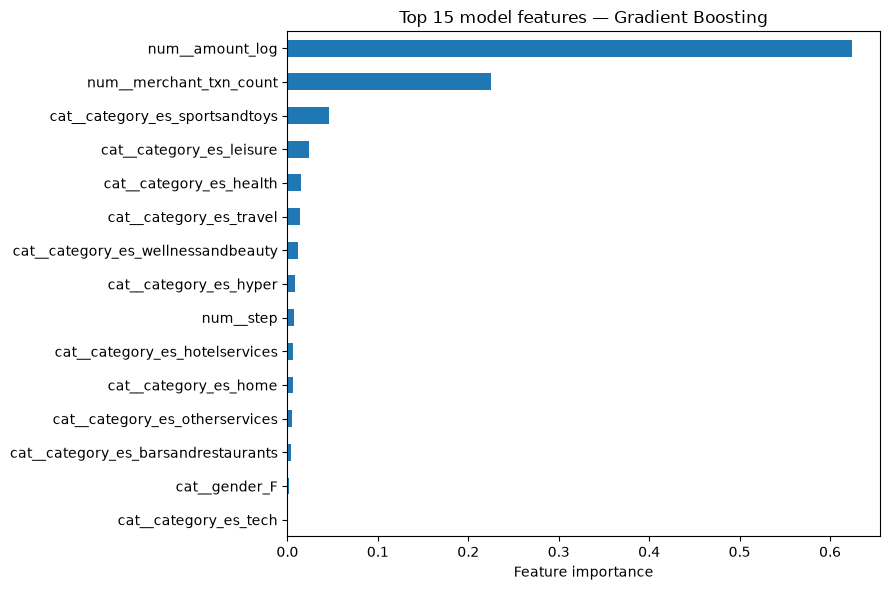

In [19]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
classifier = final_model.named_steps['clf']

if hasattr(classifier, 'feature_importances_'):
    importance_values = classifier.feature_importances_
    importance_label = 'Feature importance'
elif hasattr(classifier, 'coef_'):
    importance_values = np.abs(classifier.coef_[0])
    importance_label = 'Absolute coefficient'
else:
    importance_values = None

if importance_values is not None:
    feature_importance = (
        pd.Series(importance_values, index=feature_names)
          .sort_values(ascending=False)
    )

    display(feature_importance.head(15).to_frame(importance_label))

    fig, ax = plt.subplots(figsize=(9, 6))
    feature_importance.head(15).sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 model features — {best_name}')
    ax.set_xlabel(importance_label)
    plt.tight_layout()
    plt.show()
else:
    print('This classifier does not expose built-in feature importance values.')

## 12. Notes for the report

When you interpret the final results, focus on:
1. why class imbalance makes accuracy a poor primary metric;
2. which transaction categories and amount patterns are associated with fraud;
3. why Precision, Recall, F1, ROC-AUC, and especially PR-AUC are useful;
4. how the classification threshold changes the precision/recall trade-off;
5. limitations of the simulated dataset and the random stratified split;
6. future work, such as a temporal evaluation using earlier steps for training and later steps for testing.